# Online Shopper Purchase Prediction using Machine Learning

## Phase 1:EDA,Model valuation 

### Problem Definition
Objective

Predict whether an online visitor will make a purchase (Revenue = True) or not (Revenue = False) based on browsing behavior.

### Business Goal

Help e-commerce companies identify potential buyers and improve conversion rates.

### Target Variable

Revenue

1 = Purchase

0 = No Purchase

### Import Libraries

In [2]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

### Data Collection & Understanding

### Dataset Information
Dataset Name: Online Shoppers Intention

Rows: 12,330

Columns: 18

Type: Classification


### Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv")

In [4]:
df.shape

(12330, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(125)

In [10]:
df = df.drop_duplicates()

#### Findings:

Total Rows: 12330

Total Columns: 18

- No null values
- drop duplicated values

### Convert boolean columns to integer

In [11]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

### EDA(Exploratory Data Analysis)

### Revenue Distribution

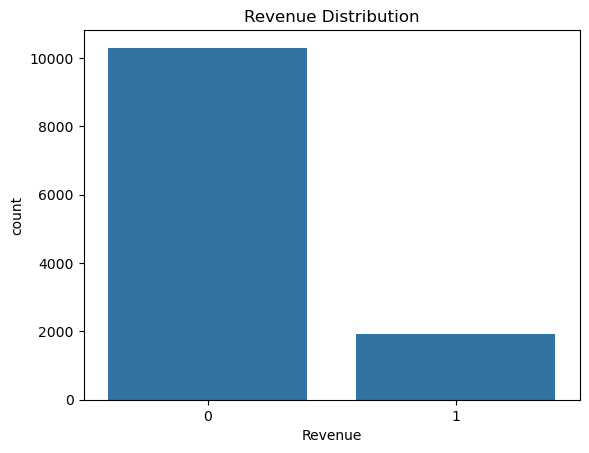

In [12]:
sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution")
plt.show()

#### Insight
- Most visitors did not make a purchase.
- The dataset is imbalanced.
- Only a small percentage of customers generated revenue.
- SMOTE is used to handle class imbalance.

### Visitor Type vs Revenue

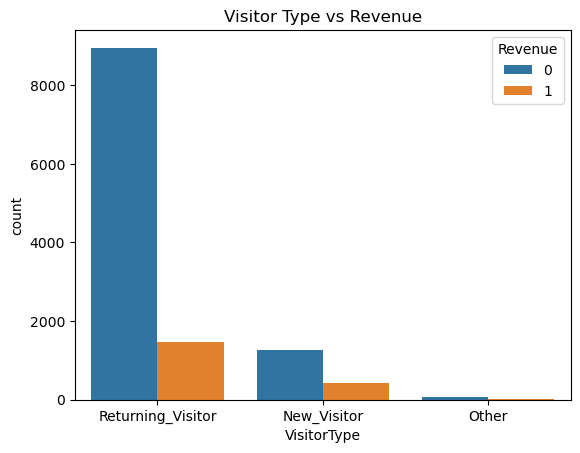

In [13]:
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Visitor Type vs Revenue")
plt.show()

### Insight
- Returning visitors generate more purchases than new visitors.
- Returning customers are more likely to buy products.
- Customer retention plays an important role in sales.

### Month vs Revenue

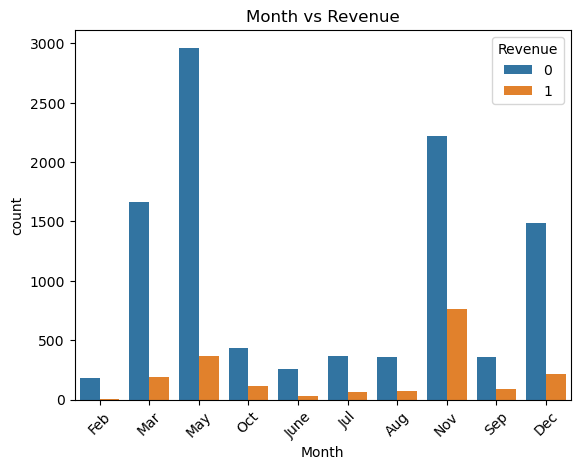

In [14]:
sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Month vs Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight
- Some months show higher purchase activity.
- Revenue tends to increase during holiday and shopping seasons.
- Customer buying behavior varies across months.

### Correlation Heatmap

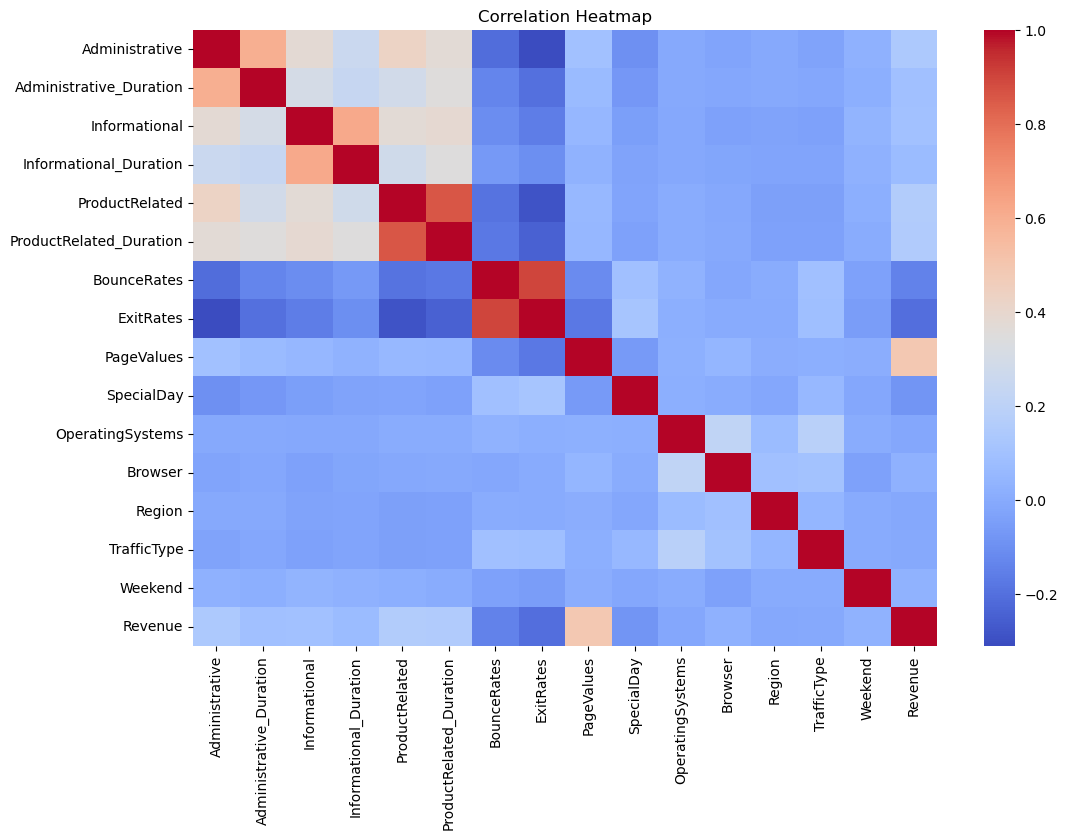

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Insight
- ProductRelated and ProductRelated_Duration show positive relationships with purchasing behavior.
- BounceRates and ExitRates are negatively associated with Revenue.
- PageValues has a strong positive correlation with Revenue.
- No severe multicollinearity is observed among most features.

### PageValues vs Revenue

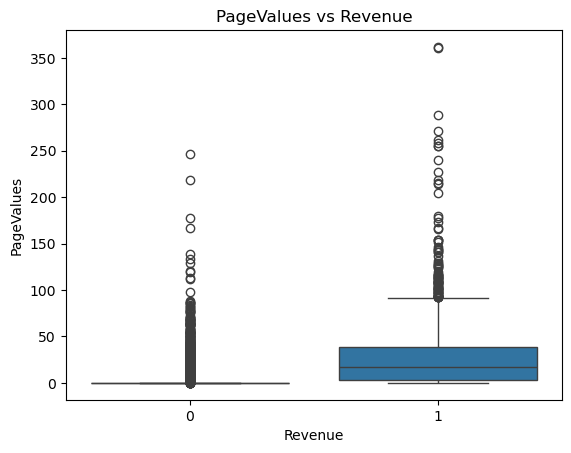

In [16]:
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("PageValues vs Revenue")
plt.show()

#### Insight
- Customers who purchased have significantly higher PageValues.
- PageValues is one of the strongest indicators of purchase intention.
- Higher PageValues generally lead to higher conversion rates.

### ExitRates vs Revenue

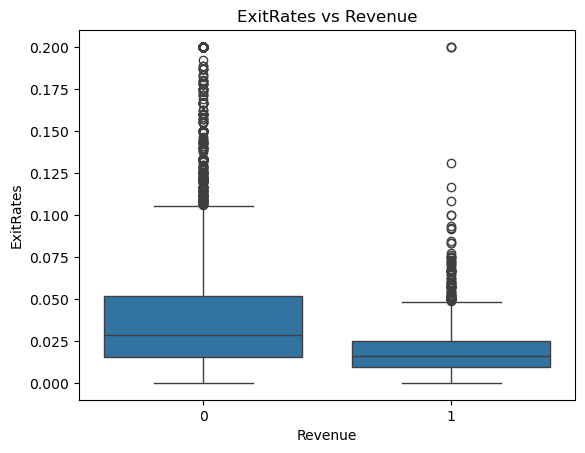

In [17]:
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("ExitRates vs Revenue")
plt.show()

### Insight
- Customers with higher Exit Rates are less likely to purchase.
- Buyers generally have lower Exit Rates.
- Exit behavior strongly influences conversion probability.

### Label Encoding

convert categorical values into Numerical values

In [18]:
le = LabelEncoder()

df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])

### Feature Engineering

In [19]:
df['Total_Duration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

df['Total_Pages'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)

df['Avg_Duration_Per_Page'] = df['Total_Duration'] / (df['Total_Pages'] + 1)

### Feature and Target Split

In [20]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

### StandardScaler

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### SMOTE only on training data

The target variable was imbalanced, so SMOTE was used to generate synthetic samples for the minority class and improve model performance.

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [24]:
y_train.value_counts()

Revenue
0    8238
1    1526
Name: count, dtype: int64

In [25]:
y_train_smote.value_counts()

Revenue
1    8238
0    8238
Name: count, dtype: int64

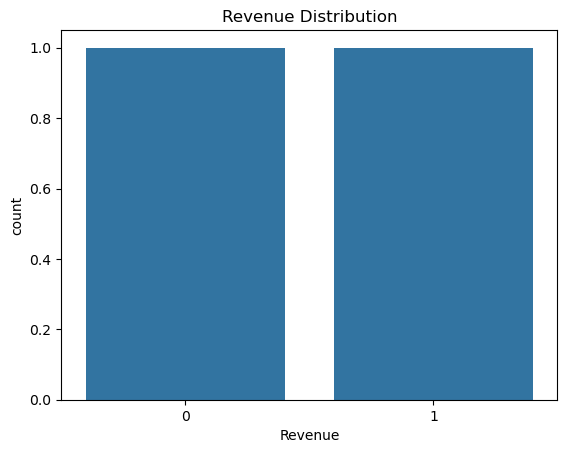

In [26]:
sns.countplot(x='Revenue', data=(pd.DataFrame(y_train_smote.value_counts())))
plt.title("Revenue Distribution")
plt.show()

### Model Evaluation and Comparison

### 1. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

Why used in this project

Since the target variable Revenue has two classes (Purchase / No Purchase), Logistic Regression can predict the probability of a customer making a purchase.

It learns the relationship between customer browsing behavior and purchase decisions.

### 2. Decision Tree Classifier

Decision Tree is a tree-based classification algorithm that makes decisions using a series of rules.

Why used in this project

It helps identify which features influence purchasing decisions the most.

The model creates rules such as:

### 3. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Why used in this project

It reduces overfitting and improves prediction accuracy.

It analyzes customer behavior using many trees and takes the majority vote to predict purchase intention.

###  4. K-Nearest Neighbors (KNN)

KNN classifies a new data point based on the majority class of its nearest neighbors.

Why used in this project

It helps compare distance-based learning with other classification models.

Customers with similar browsing behavior are grouped together to predict purchase likelihood.

### 5. Support Vector Machine (SVM)

SVM finds the optimal boundary (hyperplane) that separates classes.

Why used in this project

It performs well when classes are distinguishable.

SVM separates purchasing and non-purchasing customers based on browsing patterns.

In [27]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.874642,0.575099,0.761780,0.655405
1,Decision Tree,0.846374,0.507246,0.641361,0.566474
2,Random Forest,0.889390,0.631455,0.704188,0.665842
3,KNN,0.782466,0.392806,0.714660,0.506964
4,SVM,0.865219,0.553320,0.719895,0.625711


#### Insight:
Random Forest the best model. it provided the best balance of Accuracy, Precision, Recall, and F1-Score while reducing overfitting through ensemble learning.

In [28]:
# Classification Report for Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.63      0.70      0.67       382

    accuracy                           0.89      2441
   macro avg       0.79      0.81      0.80      2441
weighted avg       0.90      0.89      0.89      2441



### Confusion Matrix

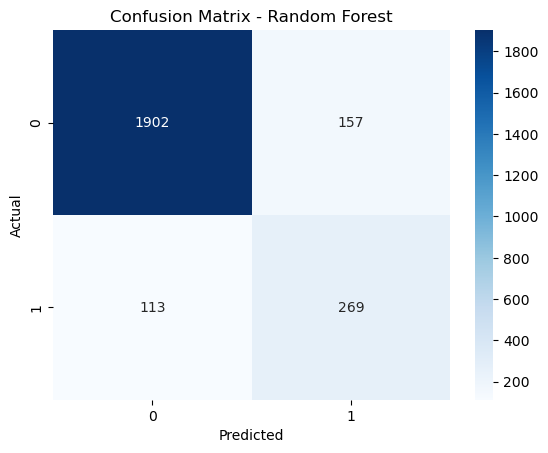

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Insight
The confusion matrix shows that the model correctly classified the majority of purchasing and non-purchasing customers. The number of True Positives and True Negatives is significantly higher than False Positives and False Negatives, indicating strong predictive performance. The model effectively identifies potential buyers while maintaining a low misclassification rate."

### Hyperparameter Tuning

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.93383197242639


In [31]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.63      0.71      0.67       382

    accuracy                           0.89      2441
   macro avg       0.79      0.82      0.80      2441
weighted avg       0.90      0.89      0.89      2441



### Prediction

In [32]:
sample = X_test[0].reshape(1, -1)

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Customer will purchase")
else:
    print("Customer will not purchase")

Customer will not purchase


### Prediction Using Unseen Data – Code

In [33]:
unseen_data = pd.DataFrame({
    'Administrative': [2],
    'Administrative_Duration': [50.0],
    'Informational': [1],
    'Informational_Duration': [20.0],
    'ProductRelated': [30],
    'ProductRelated_Duration': [1200.0],
    'BounceRates': [0.02],
    'ExitRates': [0.04],
    'PageValues': [25.0],
    'SpecialDay': [0.0],
    'Month': [5],
    'OperatingSystems': [2],
    'Browser': [2],
    'Region': [3],
    'TrafficType': [4],
    'VisitorType': [1],
    'Weekend': [1],
    'Total_Duration': [1270.0],
    'Total_Pages': [33],
    'Avg_Duration_Per_Page': [38.48]
})

In [34]:
# Scale unseen data first

unseen_data_scaled = scaler.transform(unseen_data)

prediction = best_model.predict(unseen_data_scaled)

if prediction[0] == 1:
    print("Prediction: Customer will purchase")
else:
    print("Prediction: Customer will not purchase")

Prediction: Customer will purchase


#### Phase 1 Conclusion 

This project successfully developed a machine learning model to predict whether an online shopper will make a purchase. After performing data preprocessing, EDA, feature engineering, SMOTE, model training, and hyperparameter tuning, Random Forest achieved the best performance. The model demonstrated strong predictive capability and can help e-commerce businesses identify potential customers and improve conversion rates.

### Phase 2: Machine Learning Pipeline 

Automate preprocessing and model training using a Pipeline to make the workflow cleaner, reusable, and deployment-ready.

In [35]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Load Dataset
df = pd.read_csv("online_shoppers_intention.csv")

# Convert Boolean Columns
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# Label Encoding
month_encoder = LabelEncoder()
visitor_encoder = LabelEncoder()

df['Month'] = month_encoder.fit_transform(df['Month'])
df['VisitorType'] = visitor_encoder.fit_transform(df['VisitorType'])

# Valuable Features
features = [
    'ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates',
    'VisitorType',
    'Weekend',
    'Month'
]

X = df[features]
y = df['Revenue']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# Train Model
pipeline.fit(X_train, y_train)

# Prediction on Test Data
y_pred = pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save Model
joblib.dump(pipeline, "online_shopper_model.pkl")
joblib.dump(month_encoder, "month_encoder.pkl")
joblib.dump(visitor_encoder, "visitor_encoder.pkl")

print("Model Saved Successfully")

Accuracy: 0.8673965936739659
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      2084
           1       0.55      0.74      0.63       382

    accuracy                           0.87      2466
   macro avg       0.75      0.82      0.78      2466
weighted avg       0.89      0.87      0.87      2466

Model Saved Successfully


### Prediction Using New Customer Data

In [36]:
import pandas as pd
import joblib

# Load Saved Model
model = joblib.load("online_shopper_model.pkl")

# Sample Customer Data
new_customer = pd.DataFrame({
    'ProductRelated': [50],
    'ProductRelated_Duration': [2500],
    'PageValues': [35],
    'BounceRates': [0.01],
    'ExitRates': [0.03],
    'VisitorType': [1],
    'Weekend': [1],
    'Month': [5]
})

# Predict
prediction = model.predict(new_customer)

# Probability
probability = model.predict_proba(new_customer)

print("Prediction:", prediction[0])

print("Purchase Probability:",
      round(probability[0][1] * 100, 2), "%")

if prediction[0] == 1:
    print("Customer is likely to purchase.")
else:
    print("Customer is unlikely to purchase.")

Prediction: 0
Purchase Probability: 45.0 %
Customer is unlikely to purchase.


#### phase 2 : Conclusion
The machine learning pipeline automated preprocessing, data balancing, and model training in a single workflow. This reduced manual effort, prevented data leakage, improved reproducibility, and prepared the model for deployment. The pipeline ensures that new customer data undergoes the same transformations used during training, resulting in consistent and reliable predictions

### phase 3: Deployment Streamlit

Phase 3 focuses on deploying the trained machine learning model using Streamlit. The objective is to create an interactive web application that allows users to enter customer browsing information and receive real-time purchase predictions. By integrating the trained Random Forest model with a user-friendly interface, the solution becomes accessible to non-technical users and demonstrates the practical application of machine learning in e-commerce.

### phase 3 : Conclusion

Conclusion

The machine learning model was successfully deployed using Streamlit, providing an interactive platform for predicting online shopper purchase intention. The application enables users to input customer browsing behavior and instantly receive prediction results along with purchase probability. This deployment transforms the machine learning model into a real-world decision-support tool that can help businesses identify potential buyers and improve customer targeting strategies.

### Overall Project Conclusion

Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, KNN, and SVM, were trained and evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. Hyperparameter tuning was performed to optimize model performance, and Random Forest emerged as the best-performing model.

To ensure scalability and reproducibility, a machine learning pipeline was implemented, automating preprocessing and model training steps. Finally, the trained model was deployed as an interactive Streamlit web application, allowing users to input customer browsing details and receive real-time purchase predictions.

Overall, the project demonstrates the complete machine learning lifecycle—from data preprocessing and model development to deployment—and highlights how predictive analytics can help e-commerce businesses identify potential customers, improve conversion rates, and support data-driven decision-making.